# Logistic Regression

1. What is Logistic Regression?
2. How Logistic Regression Works
3. Logistic Regression in Scikit-Learn
4. ROC Curve and AUC

## 1. What is Logistic Regression?

**Logistic Regression** is a supervised learning algorithm used for **classification problems**

Its goal is to **predict the probability that a data point belongs to a certain class**

Example:
- Will a customer subscribe? → Yes / No  
- Is an email spam? → Spam / Not Spam  

We then convert this probability into a class using a **threshold**

## 2. How Logistic Regression Works

### Step 1: Linear Combination

The model first computes a weighted sum of the features: z = w₁x₁ + w₂x₂ + ... + b

### Problem

The output of this equation can be any value ]-infinity , infinity[

But we need a probability between **0 and 1**

### Step 2: Sigmoid Function

To solve this, we apply the **sigmoid function**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$


### Step 3: Decision Boundary

We convert probability into class:

- If P ≥ 0.5 → Class 1  
- If P < 0.5 → Class 0  

This creates a **decision boundary** in the feature space.

## 3. Logistic Regression in Scikit-Learn

    from sklearn.linear_model import LogisticRegression

    model = LogisticRegression()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

## Imports

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

An experiment was conducted on 5000 participants to study the effects of age and physical health on hearing loss, specifically the ability to hear high pitched tones. This data displays the result of the study in which participants were evaluated and scored for physical ability and then had to take an audio test (pass/no pass) which evaluated their ability to hear high frequencies. The age of the user was also noted. Is it possible to build a model that would predict someone's liklihood to hear the high frequency sound based solely on their features (age and physical score)?

* Features

    * age - Age of participant in years
    * physical_score - Score achieved during physical exam

* Label/Target

    * test_result - 0 if no pass, 1 if test passed

In [ ]:
df = pd.read_csv('/content/hearing_test.csv')

In [ ]:
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             5000 non-null   float64
 1   physical_score  5000 non-null   float64
 2   test_result     5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB


In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,5000.0,51.60900,11.287001,18.0,43.0,51.0,60.0,90.0
physical_score,5000.0,32.76026,8.169802,-0.0,26.7,35.3,38.9,50.0
test_result,5000.0,0.60000,0.489947,0.0,0.0,1.0,1.0,1.0


### Train | Test Split and Scaling

In [ ]:
X = df.drop('test_result',axis=1)
y = df['test_result']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [ ]:
scaler = StandardScaler()

In [ ]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

## Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_model = LogisticRegression()

In [ ]:
log_model.fit(scaled_X_train,y_train)

LogisticRegression()

### Model Performance on Classification Tasks

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import ConfusionMatrixDisplay


In [ ]:
y_pred = log_model.predict(scaled_X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.93

In [ ]:
confusion_matrix(y_test,y_pred)

array([[172,  21],
       [ 14, 293]])

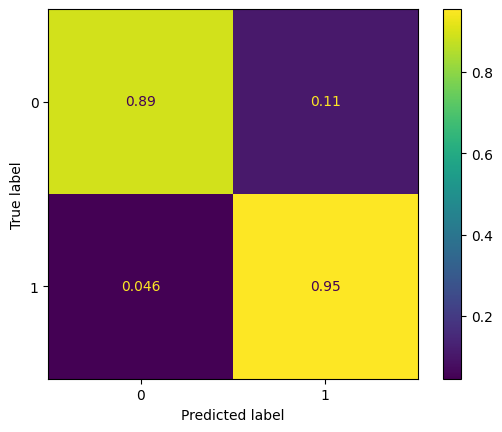

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize='true'
)

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       193
           1       0.93      0.95      0.94       307

    accuracy                           0.93       500
   macro avg       0.93      0.92      0.93       500
weighted avg       0.93      0.93      0.93       500



## ROC and AUC

    model.predict_proba(X_test)

Output (threshold = 0.5):

    [[0.8, 0.2],

    [0.3, 0.7],

    [0.1, 0.9]]


    model.predict_proba(X_test)[:,1]

Output:
    [0.2, 0.7, 0.9]


#### Note: The threshold is not fixed.

We can change it:

Threshold = 0.3 → more positives predicted
Threshold = 0.7 → fewer positives predicted

Each threshold produces different:

- True Positives (TP)

- False Positives (FP)

- False Negatives (FN)

- True Negatives (TN)

## 5. ROC Curve and AUC

Instead of choosing a single threshold, the ROC curve evaluates all possible thresholds.

### What is ROC Curve?

The **ROC (Receiver Operating Characteristic) curve** shows the performance of a classification model at different threshold values. It summarizes all the confusions matrices that each threshold produced

It plots:

- **True Positive Rate (TPR)** → measures how many actual positives are correctly identified (Recall)

$$
TPR = \frac{TP}{TP + FN}
$$

- **False Positive Rate (FPR)** → measures how many negatives are incorrectly classified as positive

$$
FPR = \frac{FP}{FP + TN}
$$

Instead of fixing the threshold at 0.5, ROC evaluates the model across **all possible thresholds**.

### ROC Curve Interpretation
- Each point on the curve corresponds to a different threshold
- The curve shows the trade-off between detecting positives and making false alarms

### Interpretation
- Curve closer to top-left corner (0.9 – 1.0) → better model
- Diagonal line (0.5) → random guessing



## AUC (Area Under the Curve)

**AUC (Area Under the ROC Curve)** measures the overall ability of a model to **distinguish between classes**.

It summarizes the entire ROC curve into a **single value**.



## When Comparing Models

- The model with **higher AUC is generally better**:
  - Only if the comparison is done on the **same dataset**
  - AUC does not tell you the best threshold to use
  - Two models may have similar AUC but behave differently at specific thresholds

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


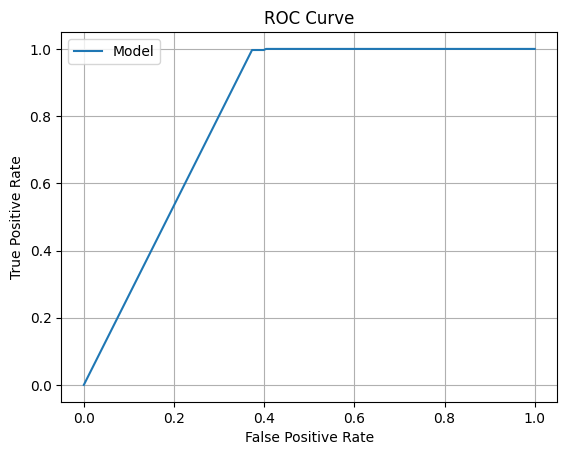

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

In [ ]:
fpr, tpr, thresholds

(array([0.        , 0.37305699, 0.38860104, 0.39896373, 0.40414508,
        0.41450777, 1.        ]),
 array([0.        , 0.99674267, 0.99674267, 0.99674267, 1.        ,
        1.        , 1.        ]),
 array([           inf, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00, 2.59429057e-16]))

In [ ]:
roc_auc_score(y_test, y_prob)

np.float64(0.8127710924710132)